# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [12]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

In [13]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [14]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [15]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialisation des outils
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    """Nettoie le texte : minuscules, tokenisation, retrait ponctuation/stopwords et lemmatisation."""
    # 1. Passage en minuscules
    text = text.lower()

    # 2. Tokenisation (découpage en mots)
    tokens = word_tokenize(text)

    # 3. Retrait de la ponctuation et des caractères spéciaux
    # On ne garde que les tokens alphanumériques
    tokens = [t for t in tokens if t not in string.punctuation and re.match(r'^[\w]+$', t)]

    # 4. Retrait des 'stopwords' (mots vides comme 'the', 'is', etc.)
    tokens = [t for t in tokens if t not in stop_words]

    # 5. Lemmatisation (ramener le mot à sa racine, ex: 'dishes' -> 'dish')
    cleaned_tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # 6. Reconstruction de la chaîne de caractères
    return " ".join(cleaned_tokens)

# Test rapide pour vérifier le fonctionnement
test_clean = preprocess_text(raw_reviews[0])
print(f"Exemple de nettoyage :\nAvant: {raw_reviews[0]}\nAprès: {test_clean}")

Exemple de nettoyage :
Avant: At McDonald's the food was ok and the service was bad.
Après: mcdonald food ok service bad


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [16]:
# On applique la fonction de nettoyage à toute notre liste de reviews
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

# Affichage comparatif pour vérification
for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")

RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW: The 

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [17]:
def perform_ner(text: str):
    """Identifie les entités nommées (Lieux, Organisations, Dates...) avec spaCy."""
    # On passe le texte dans le modèle spaCy chargé (nlp)
    doc = nlp(text)

    # On extrait le texte de l'entité et son label (ORG, GPE, etc.)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

# Test sur une phrase
print("Test NER:", perform_ner(raw_reviews[4]))

Test NER: [('Google', 'ORG')]


### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [18]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Identifie la fonction grammaticale de chaque mot (Nom, Verbe, Adjectif...)."""
    # 1. Tokenisation obligatoire avant le POS tagging
    tokens = word_tokenize(text)

    # 2. Application du tagger NLTK
    return pos_tag(tokens)

# Test sur une phrase
print("Test POS:", perform_pos_tagging(raw_reviews[0]))

Test POS: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [19]:
sample_texts = raw_reviews[:2]
sample_cleaned = cleaned_reviews[:2]

print("--- ANALYSE NER (Entités Nommées) ---")
for r, c in zip(sample_texts, sample_cleaned):
    print(f"Raw: {perform_ner(r)}")
    print(f"Cleaned: {perform_ner(c)}") # Notez que le nettoyage peut nuire à la détection NER

print("\n--- ANALYSE POS (Grammaire) ---")
for r, c in zip(sample_texts, sample_cleaned):
    print(f"Raw POS: {perform_pos_tagging(r)[:5]}...")
    print(f"Cleaned POS: {perform_pos_tagging(c)[:5]}...")

--- ANALYSE NER (Entités Nommées) ---
Raw: [('McDonald', 'ORG')]
Cleaned: [('mcdonald food ok service', 'ORG')]
Raw: [('Japanese', 'NORP')]
Cleaned: [('japanese', 'NORP')]

--- ANALYSE POS (Grammaire) ---
Raw POS: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN')]...
Cleaned POS: [('mcdonald', 'NNS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]...
Raw POS: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT')]...
Cleaned POS: [('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]...


## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [20]:
from gensim.models import Word2Vec

# Word2Vec attend une liste de listes (phrases tokenisées)
tokenized_reviews = [review.split() for review in cleaned_reviews]

# Entraînement du modèle
# vector_size=100 : chaque mot sera représenté par 100 chiffres
# window=5 : contexte de 5 mots autour
# min_count=1 : on garde tous les mots, même rares pour cet exercice
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, workers=4)

print("Modèle Word2Vec entraîné avec succès.")

Modèle Word2Vec entraîné avec succès.


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [21]:
# Analyse des dimensions
vocab_size = len(w2v_model.wv)
vector_dim = w2v_model.vector_size

print(f"Taille du vocabulaire : {vocab_size} mots")
print(f"Dimension des vecteurs : {vector_dim}")

# Explication :
# La dimension (100) représente l'espace sémantique. Chaque coordonnée capture
# une 'caractéristique' abstraite du mot apprise par le modèle.

Taille du vocabulaire : 55 mots
Dimension des vecteurs : 100


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

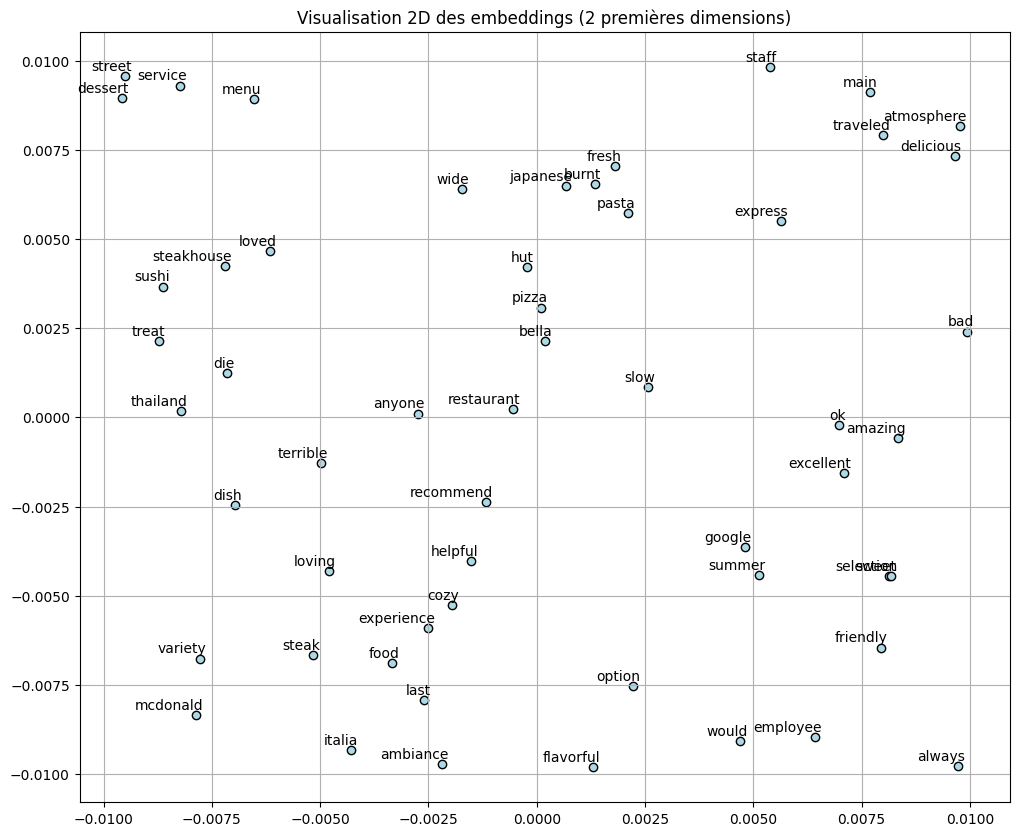

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_word_embeddings(model):
    # On récupère les mots du vocabulaire
    words = list(model.wv.index_to_key)
    # On récupère leurs vecteurs
    vectors = [model.wv[word] for word in words]

    # Pour l'exercice, on ne garde que les 2 premières dimensions pour l'affichage 2D
    vectors_2d = np.array(vectors)[:, :2]

    plt.figure(figsize=(12, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='lightblue')

    # Ajout des labels pour chaque point
    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom')

    plt.title("Visualisation 2D des embeddings (2 premières dimensions)")
    plt.grid(True)
    plt.show()

# Lancer la visualisation
plot_word_embeddings(w2v_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

### 2.4.1 Expérimentation avec les Bigrams
Les bigrams permettent de lier des mots qui vont souvent ensemble (ex: 'pizza' + 'hut' = 'pizza_hut').

In [23]:
from gensim.models.phrases import Phrases, Phraser

# Détection des phrases communes (bigrams)
phrases = Phrases(tokenized_reviews, min_count=1, threshold=2)
bigram_model = Phraser(phrases)

# Application aux reviews
tokenized_bigrams = [bigram_model[sent] for sent in tokenized_reviews]

print("Exemple avec bigrams :", tokenized_bigrams[6]) # Devrait montrer 'pizza_hut'

Exemple avec bigrams : ['terrible', 'experience', 'pizza', 'hut', 'pizza', 'burnt', 'service', 'slow']


```markdown
### 📝 Analyse des Bigrams
Dans l'exemple ci-dessus, vous avez peut-être remarqué que `pizza` et `hut` sont restés séparés au lieu de former `pizza_hut`.

**Pourquoi ?**
L'algorithme de détection de phrases se base sur la fréquence d'apparition simultanée. Comme notre dataset ne contient que 10 lignes, la force statistique n'est pas suffisante pour que le modèle soit "sûr" qu'il s'agisse d'une expression figée. Sur un dataset réel (milliers de lignes), ces mots auraient été fusionnés automatiquement.
```

### 2.4.2 Fine-tuning du modèle Word2Vec
Utilisons l'algorithme **Skip-gram** (`sg=1`) qui est souvent plus performant sur de petits datasets pour capturer les relations entre mots rares.

In [24]:
# sg=1 active Skip-gram (plus lent mais souvent meilleur pour les petits jeux de données)
# window=2 réduit le contexte pour être très spécifique aux voisins immédiats
w2v_tuned = Word2Vec(sentences=tokenized_bigrams, vector_size=50, window=2, sg=1, min_count=1)

print("Modèle optimisé entraîné.")

Modèle optimisé entraîné.


```markdown
### 📝 Pourquoi utiliser Skip-gram (sg=1) ?
Il existe deux architectures principales pour Word2Vec :
1. **CBOW** : Prédit un mot à partir de son contexte (rapide, efficace pour les mots fréquents).
2. **Skip-gram** : Prédit le contexte à partir d'un mot.

**Le choix :** Pour les petits volumes de données comme le nôtre, **Skip-gram** est préférable car il permet de mieux capturer les relations sémantiques entre les mots, même s'ils apparaissent rarement.
```

### 2.4.3 Visualisation avancée avec PCA
Au lieu de prendre arbitrairement les deux premières dimensions, la PCA (Analyse en Composantes Principales) compresse toute l'information mathématique en 2 dimensions.

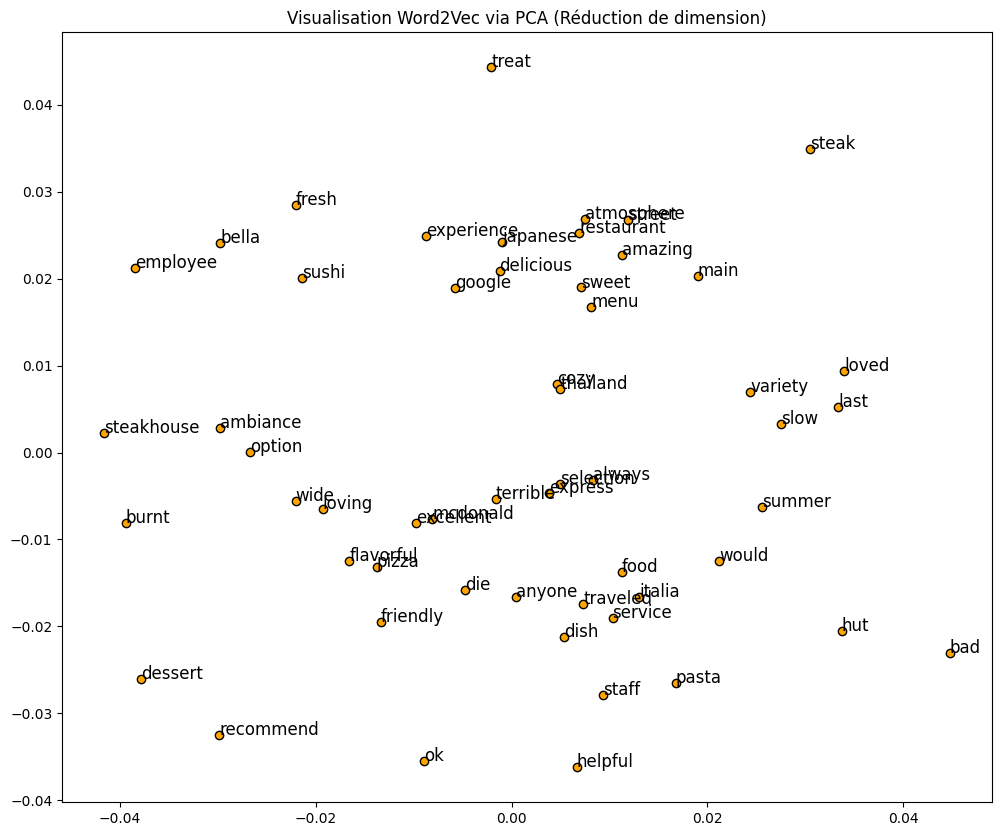

In [25]:
from sklearn.decomposition import PCA

def plot_with_pca(model):
    words = list(model.wv.index_to_key)
    vectors = [model.wv[word] for word in words]

    # On utilise PCA pour réduire de 50 (ou 100) dimensions à 2
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    plt.figure(figsize=(12, 10))
    plt.scatter(result[:, 0], result[:, 1], c='orange', edgecolors='k')

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), size=12)

    plt.title("Visualisation Word2Vec via PCA (Réduction de dimension)")
    plt.show()

plot_with_pca(w2v_tuned)

```markdown
### 📝 L'apport de la PCA (Analyse en Composantes Principales)
Dans notre première visualisation (Exercice 2.3), nous affichions simplement les deux premières colonnes de nos vecteurs de dimension 100. C'est une vision très limitée.

**Comment fonctionne la PCA ?**
La PCA est un algorithme mathématique qui réduit la dimensionnalité en projetant les données sur les axes qui conservent le maximum de variance (d'information).

**Résultat :** Les distances que vous voyez sur ce graphique orange sont beaucoup plus représentatives de la réalité mathématique du modèle que sur le graphique précédent.
```